c:\Users\fpenaherrera_vaca\.conda\envs\pypsa-earth-ec\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\fpenaherrera_vaca\.conda\envs\pypsa-earth-ec\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\fpenaherrera_vaca\.conda\envs\pypsa-earth-ec\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\fpenaherrera_vaca\.conda\envs\pypsa-earth-ec\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn

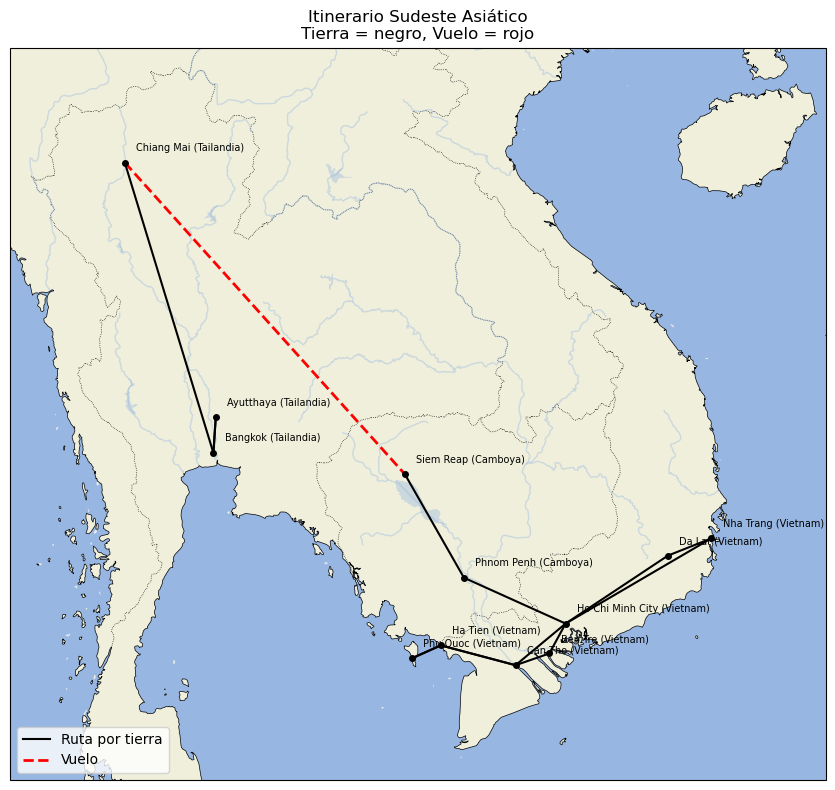

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================
# 1. PUNTOS DEL ITINERARIO
# =========================

locations = {
    "Bangkok (Tailandia)":      {"lat": 13.736717, "lon": 100.523186},
    "Ayutthaya (Tailandia)":    {"lat": 14.353543, "lon": 100.564568},
    "Chiang Mai (Tailandia)":   {"lat": 18.796143, "lon": 98.979263},
    "Siem Reap (Camboya)":      {"lat": 13.364047, "lon": 103.860313},
    "Phnom Penh (Camboya)":     {"lat": 11.562108, "lon": 104.888535},
    "Ho Chi Minh City (Vietnam)": {"lat": 10.762622, "lon": 106.660172},
    "Ben Tre (Vietnam)":        {"lat": 10.241500, "lon": 106.376000},
    "Can Tho (Vietnam)":        {"lat": 10.037110, "lon": 105.788250},
    "Ha Tien (Vietnam)":        {"lat": 10.382802, "lon": 104.485950},
    "Phu Quoc (Vietnam)":       {"lat": 10.158625, "lon": 103.984020},
    "Nha Trang (Vietnam)":      {"lat": 12.245070, "lon": 109.194320},
    "Da Lat (Vietnam)":         {"lat": 11.946460, "lon": 108.441930},
}

# =========================
# 2. RUTAS (ORIGEN, DESTINO, MODO)
# =========================
# modo: "land" (tierra = negro), "flight" (vuelo = rojo)

routes = [
    # Tailandia
    ("Bangkok (Tailandia)", "Ayutthaya (Tailandia)", "land"),
    ("Ayutthaya (Tailandia)", "Bangkok (Tailandia)", "land"),
    ("Bangkok (Tailandia)", "Chiang Mai (Tailandia)", "land"),  # tren

    # Vuelo único
    ("Chiang Mai (Tailandia)", "Siem Reap (Camboya)", "flight"),

    # Camboya
    ("Siem Reap (Camboya)", "Phnom Penh (Camboya)", "land"),

    # Vietnam - sur + Mekong
    ("Phnom Penh (Camboya)", "Ho Chi Minh City (Vietnam)", "land"),
    ("Ho Chi Minh City (Vietnam)", "Ben Tre (Vietnam)", "land"),
    ("Ben Tre (Vietnam)", "Can Tho (Vietnam)", "land"),
    ("Can Tho (Vietnam)", "Ha Tien (Vietnam)", "land"),
    ("Ha Tien (Vietnam)", "Phu Quoc (Vietnam)", "land"),

    # regreso y continuación por Vietnam
    ("Phu Quoc (Vietnam)", "Ha Tien (Vietnam)", "land"),
    ("Ha Tien (Vietnam)", "Can Tho (Vietnam)", "land"),
    ("Can Tho (Vietnam)", "Ho Chi Minh City (Vietnam)", "land"),
    ("Ho Chi Minh City (Vietnam)", "Nha Trang (Vietnam)", "land"),
    ("Nha Trang (Vietnam)", "Da Lat (Vietnam)", "land"),
    ("Da Lat (Vietnam)", "Ho Chi Minh City (Vietnam)", "land"),
]

# =========================
# 3. CREAR FIGURA CARTOPY
# =========================

# Proyección geográfica simple (lon/lat)
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=proj)

# Extent aproximado: (lon_min, lon_max, lat_min, lat_max)
all_lats = [c["lat"] for c in locations.values()]
all_lons = [c["lon"] for c in locations.values()]

margin_lat = 2.0
margin_lon = 2.0

lon_min = min(all_lons) - margin_lon
lon_max = max(all_lons) + margin_lon
lat_min = min(all_lats) - margin_lat
lat_max = max(all_lats) + margin_lat

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# =========================
# 4. FONDO DEL MAPA
# =========================

# Tierra, océanos, fronteras y costas
ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.4)
ax.add_feature(cfeature.RIVERS, alpha=0.4)

# =========================
# 5. DIBUJAR PUNTOS Y ETIQUETAS
# =========================

for name, coord in locations.items():
    x = coord["lon"]
    y = coord["lat"]
    # punto
    ax.plot(x, y, marker="o", markersize=4, transform=proj, color="black", zorder=3)
    # etiqueta (ligeramente desplazada)
    ax.text(x + 0.2, y + 0.2, name, fontsize=7, transform=proj)

# =========================
# 6. DIBUJAR RUTAS
# =========================

for origin, dest, mode in routes:
    x0, y0 = locations[origin]["lon"], locations[origin]["lat"]
    x1, y1 = locations[dest]["lon"], locations[dest]["lat"]

    if mode == "flight":
        color = "red"
        linestyle = "--"
        lw = 2.0
    else:
        color = "black"
        linestyle = "-"
        lw = 1.5

    ax.plot(
        [x0, x1],
        [y0, y1],
        color=color,
        linestyle=linestyle,
        linewidth=lw,
        transform=proj,
        zorder=2,
    )

# =========================
# 7. LEYENDA SIMPLE
# =========================

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Ruta por tierra"),
    Line2D([0], [0], color="red", lw=2.0, linestyle="--", label="Vuelo"),
]

ax.legend(handles=legend_elements, loc="lower left")

ax.set_title("Itinerario Sudeste Asiático\nTierra = negro, Vuelo = rojo", fontsize=12)

plt.tight_layout()
plt.show()
